<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB8_Data_Bining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Transformation: Data Binning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data Loading
#titanic = pd.read_csv('titanic.csv')
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Una de las maneras más sencillas de visualizar la distribución de información es por medio de un histograma como se muestra a continuación.

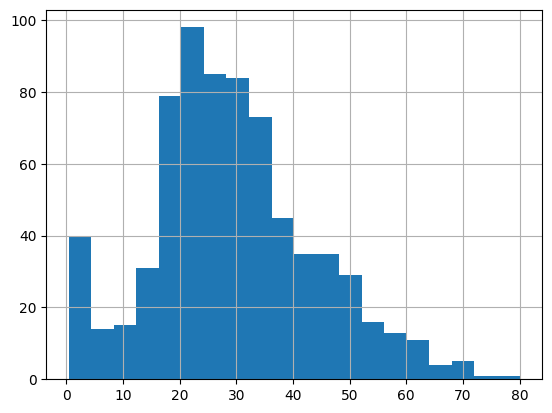

In [ ]:
titanic['age'].hist(bins=20)
plt.show()

Sin embargo, existen muchos escenarios en las que es deseable definir límites manualmente. Por ejemplo, en el caso de las edades tiene más sentido trabajar con rangos de edades definidos por etapas, o simplemente tener control sobre la cantidad de agrupaciones que se requiere.

Para ello, Pandas tienes dos funciones que pueden ayudar al respecto: `.qcut(...)`, el cual divide con base a quantile; y `.cut(...)`, que divide en relación al rango de valores.

## qcut
La principal funcionalidad de este método es que intenta dividir la data en agrupaciones de aproximadamente el mismo tamaño, es decir, que contangan una cantidad similar de elementos. Las divisiones se crean con base a los quantiles, y no con lo valores numéricos.

El método `.describe()` permite ver una primera aproximación del concepto:

In [ ]:
titanic['age'].describe()

,age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


Los quartiles pueden identificarse con base en esto, y si se comparan con los que se obtienen de hacer la división de `.qcut(...)` para 4 agrupaciones se puede ver que son los mismos límites:

Además, que también equilibrados están las agrupaciones se puede analizar contando los valores resultanted de la agrupación. Adicionalmente, se puede realizar una gráfica para confirmar visualmente.

In [ ]:
titanic['age'].head()

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [ ]:
pd.qcut(titanic['age'], q=4).value_counts(sort=False)

,count
age,
"(0.419, 20.125]",179
"(20.125, 28.0]",183
"(28.0, 38.0]",175
"(38.0, 80.0]",177


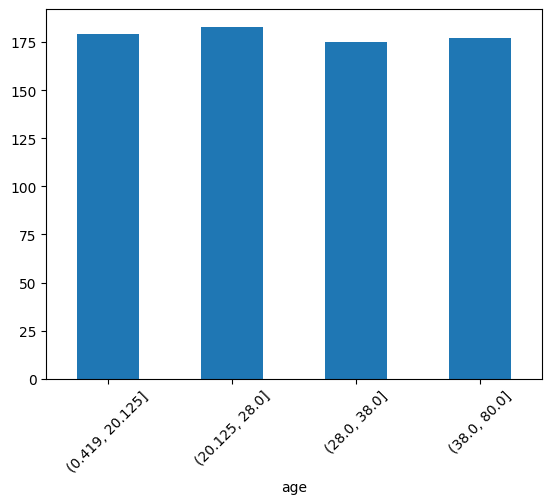

In [ ]:
pd.qcut(titanic['age'], q=4).value_counts(sort=False).plot(kind = "bar", rot=45)
plt.show()

A continuación se observa un ejemplo de enriquecimiento de la tabla con el resultado de la agrupación para diferentes valores.

In [ ]:
#q=4 -> Cuartiles
#q=10 -> Deciles
#q=100 -> Percentiles
titanic['age_q_4'] = pd.qcut(titanic['age'], q=4)
titanic['age_q_10'] = pd.qcut(titanic['age'], q=10)

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_q_4,age_q_10
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,"(20.125, 28.0]","(19.0, 22.0]"
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,"(28.0, 38.0]","(36.0, 41.0]"
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,"(20.125, 28.0]","(25.0, 28.0]"
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,"(28.0, 38.0]","(31.8, 36.0]"
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,"(28.0, 38.0]","(31.8, 36.0]"


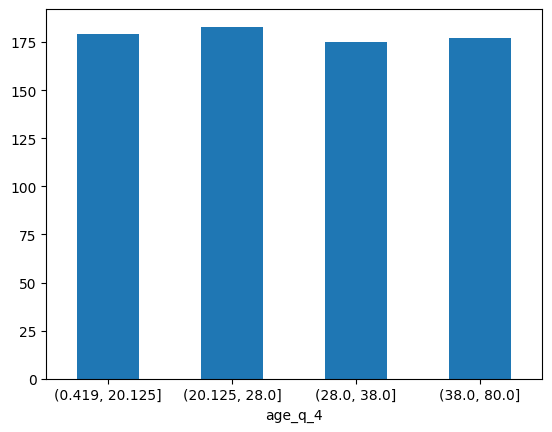

In [ ]:
titanic['age_q_4'].value_counts(sort=False).plot(kind = "bar", rot=0)
plt.show()

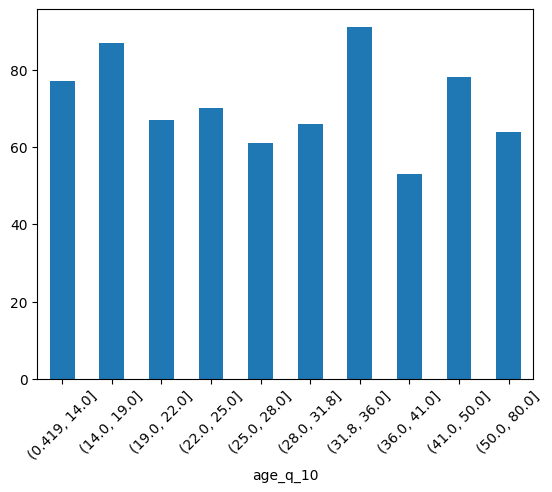

In [ ]:
titanic['age_q_10'].value_counts(sort=False).plot(kind = "bar", rot = 45)
plt.show()

Hasta ahora, el único identificador de cada agrupación es el rango o límites de éste. Si quisiéramos tener no solamente agrupaciones identificadas con ciertas etiquetas, pero que además los límites quantiles no sean uniformes, se puede utilizar dos parámetros:
* `q=` En lugar de indicar un número, se pasa una lista de valores en el rango de 0 y 1.
* `labels=` Una lista con las etiquetas correspondientes para cada una de las agrupaciones.

In [ ]:
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Elder']
titanic['age_labels'] = pd.qcut(titanic['age'], q=5, labels=age_labels)
titanic['age_q_5'] = pd.qcut(titanic['age'], q=5)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_q_4,age_q_10,age_labels,age_q_5
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,"(20.125, 28.0]","(19.0, 22.0]",Teen,"(19.0, 25.0]"
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,"(28.0, 38.0]","(36.0, 41.0]",Adult,"(31.8, 41.0]"
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,"(20.125, 28.0]","(25.0, 28.0]",Young Adult,"(25.0, 31.8]"
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,"(28.0, 38.0]","(31.8, 36.0]",Adult,"(31.8, 41.0]"
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,"(28.0, 38.0]","(31.8, 36.0]",Adult,"(31.8, 41.0]"


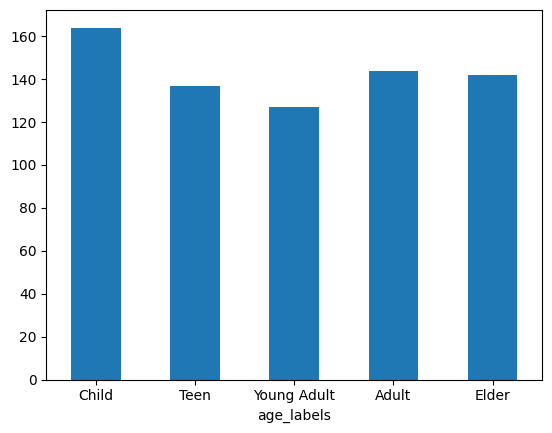

In [ ]:
titanic['age_labels'].value_counts(sort=False).plot(kind = "bar", rot=0)
plt.show()

En caso de que se requiera saber cuales fueron los límites que definen cada categoría, se puede utilizar el parámetro `retbins=` para que adicionalmente se devuelva una lista con los valores de frontera de cada grupo.

In [ ]:
results, bin_edges = pd.qcut(titanic['age'], q=5, labels=age_labels, retbins=True)

In [ ]:
qcut_output = pd.qcut(titanic['age'], q=5, labels=age_labels, retbins=True)

In [ ]:
qcut_output

(0             Teen
 1            Adult
 2      Young Adult
 3            Adult
 4            Adult
           ...     
 886    Young Adult
 887          Child
 888            NaN
 889    Young Adult
 890          Adult
 Name: age, Length: 891, dtype: category
 Categories (5, object): ['Child' < 'Teen' < 'Young Adult' < 'Adult' < 'Elder'],
 array([ 0.42, 19.  , 25.  , 31.8 , 41.  , 80.  ]))

In [ ]:
results

,age
0,Teen
1,Adult
2,Young Adult
3,Adult
4,Adult
...,...
886,Young Adult
887,Child
888,NaN
889,Young Adult


In [ ]:
bin_edges

array([ 0.42, 19.  , 25.  , 31.8 , 41.  , 80.  ])

In [ ]:
for category in zip(age_labels, bin_edges):
    print(category)

('Child', np.float64(0.42))
('Teen', np.float64(19.0))
('Young Adult', np.float64(25.0))
('Adult', np.float64(31.800000000000068))
('Elder', np.float64(41.0))


Una alternativa más, es que en el caso de que no se desee utilizar los rangos como los identificadores, pero no se cuenta con una lista de etiquetas, se indica `False` en el parámetro de `labels=` y se etiquetan con valores numéricos ordinales.

In [ ]:
titanic['age_q_4v1'] = pd.qcut(titanic['age'], q=4)
titanic['age_q_4v2'] = pd.qcut(titanic['age'], q=4, labels=False)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,age_q_4,age_q_10,age_labels,age_q_5,age_q_4v1,age_q_4v2
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,"(20.125, 28.0]","(19.0, 22.0]",Teen,"(19.0, 25.0]","(20.125, 28.0]",1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,"(28.0, 38.0]","(36.0, 41.0]",Adult,"(31.8, 41.0]","(28.0, 38.0]",2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,"(20.125, 28.0]","(25.0, 28.0]",Young Adult,"(25.0, 31.8]","(20.125, 28.0]",1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,"(28.0, 38.0]","(31.8, 36.0]",Adult,"(31.8, 41.0]","(28.0, 38.0]",2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,"(28.0, 38.0]","(31.8, 36.0]",Adult,"(31.8, 41.0]","(28.0, 38.0]",2.0


## cut
Como se mencionó anteriormente, este método sirve para cuando se desea realizar la categorización de los datos no con base en la cantidad de datos que debe de haber en cada categoría, sino en el rango de éstas.

En su forma más simple, se define la cantidad de agrupaciones con el parámetro `bins=` y se divide de forma uniforme el rango completo de valores.

In [ ]:
pd.cut(titanic['age'], bins=4).value_counts()

,count
age,
"(20.315, 40.21]",385
"(0.34, 20.315]",179
"(40.21, 60.105]",128
"(60.105, 80.0]",22


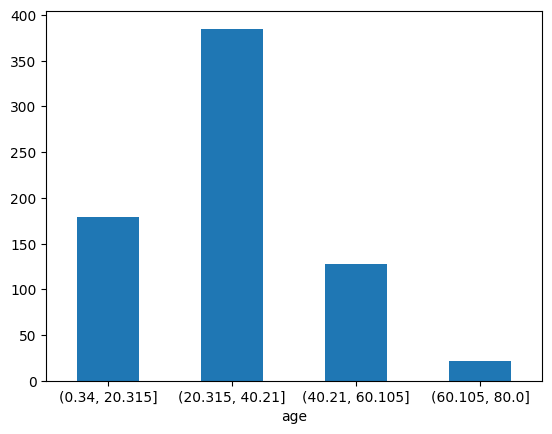

In [ ]:
pd.cut(titanic['age'], bins=4).value_counts(sort=False).plot(kind = "bar", rot=0)
plt.show()

Como puede observarse en el conteo de valores y la gráfica de barras, la distribución de elementos no es uniforme sino que los límites de cada categoría está uniformemente distribuida en el rango completo de valores.

Similarmente, en este método se pueden definir los límites de cada grupo y las etiquetas de los mismos:
* `bins=` En lugar de indicar un número, se pasa una lista de valores.
* `labels=` Una lista con las etiquetas de cada una de las agrupaciones.

In [ ]:
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Elder']
age_limits = [0, 14, 29, 44, 64, 100]
titanic['age_labels'] = pd.cut(titanic['age'], bins=age_limits, labels=age_labels)

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,age_q_4,age_q_10,age_labels,age_q_5,age_q_4v1,age_q_4v2
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,"(20.125, 28.0]","(19.0, 22.0]",Teen,"(19.0, 25.0]","(20.125, 28.0]",1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,"(28.0, 38.0]","(36.0, 41.0]",Young Adult,"(31.8, 41.0]","(28.0, 38.0]",2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,"(20.125, 28.0]","(25.0, 28.0]",Teen,"(25.0, 31.8]","(20.125, 28.0]",1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,"(28.0, 38.0]","(31.8, 36.0]",Young Adult,"(31.8, 41.0]","(28.0, 38.0]",2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,"(28.0, 38.0]","(31.8, 36.0]",Young Adult,"(31.8, 41.0]","(28.0, 38.0]",2.0


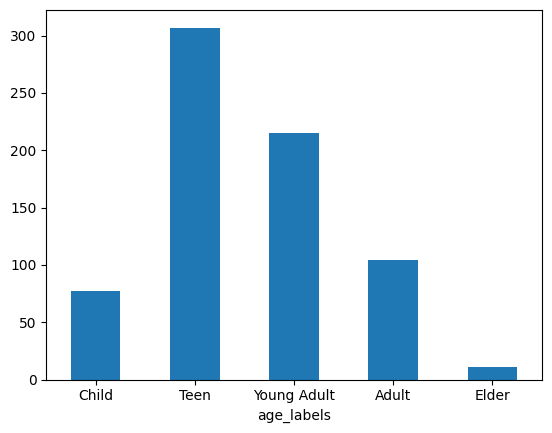

In [ ]:
titanic['age_labels'].value_counts(sort=False).plot.bar(rot=0)
plt.show()

## Conclusión
Existen diferentes maneras de poder agrupar los datos. Dos de los métodos principales difieren si se desea dividir en función de la cantidad de datos en cada grupo o en cambio se desea controlar los límites de cada categoría. En ambos casos, se puede tener un control preciso de los detalles de la división, como también del manejo de los resultados devueltos.